In [1]:
import numpy as np
from scipy import constants
import pandas as pd
import matplotlib.pyplot as plt
from tweezer_functions import * 
from IonChainTools import *
from scipy.optimize import fsolve
import matplotlib.colors as mcolors
import matplotlib.colorbar as mcolorbar
from scipy.optimize import fsolve
from scipy.optimize import curve_fit
from scipy.optimize import minimize
import matplotlib.ticker as ticker

#Constants in SI units
eps0 = constants.epsilon_0 
mBa137 = 136.9058 * constants.atomic_mass
mBa138 = 137.905232 * constants.atomic_mass
c = constants.c
e = constants.e
hbar = constants.hbar
h = constants.h 
pi = np.pi

# setting up parameters that we're not changing
tweezer_wavelength = 532e-9
omega_tweezer = 2*pi*c/tweezer_wavelength
print(omega_tweezer)
linewidths = np.array([2*pi*20.5e6,2*pi*25.2e6])
branching_ratios = np.array([0.732,0.702])
linewidths = linewidths * branching_ratios
print(linewidths)
lambda_res = np.array([493.545e-9,455.531e-9])
print(lambda_res)

omega_res = 2*pi*c/lambda_res
lifetimes = linewidths


#test

3540698434791077.0
[9.42854787e+07 1.11152061e+08]
[4.93545e-07 4.55531e-07]


In [2]:
print(mBa137)

2.273374293441263e-25


# 3 ion chain, tables showing full motional mode spectrum for P = 96 mW

## Tweezing the outer ion

In [7]:
w_rf_r = 2*pi*3e6
w_rf_a = 2*pi*400e3
w_tw_r = 2*pi*150e3
w_tw_a = None
N = 3
w_comb_r = combined_frequencies(N,[0],w_tw_r,w_tw_a,w_rf_r,w_rf_a)[0]
w_comb_a = combined_frequencies(N,[0],w_tw_r,w_tw_a,w_rf_r,w_rf_a)[2]
ueq = ion_spacing(N,w_rf_a)[0]
base_modes = individual_freqs_to_mode_vectors(N,[0],0,0,w_rf_r,w_rf_a,ueq)
tweezed_modes = individual_freqs_to_mode_vectors(N,[0],w_tw_r,w_tw_a,w_rf_r,w_rf_a,ueq)

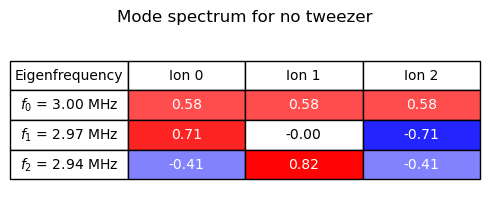

In [8]:
# Make figure and axis
fig, ax = plt.subplots(figsize=(5, 0.7 * len(base_modes)))
ax.axis('tight')
ax.axis('off')

# Prepare table data
table_data = []
for index, (omega, etas) in enumerate(base_modes):
    omega_mhz = omega / 1e6
    formatted_values = [f"{eta:.2f}" for eta in etas]
    omega_label = f"$f_{{{index}}}$ = {omega_mhz:.2f} MHz"
    table_data.append([omega_label] + formatted_values)

# Create column labels
column_labels = ["Eigenfrequency"] + [f"Ion {i}" for i in range(len(base_modes))]

# Build the table
table = ax.table(cellText=table_data, colLabels=column_labels, loc='center', cellLoc='center')

# Style
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.6)

# Colormap normalization
etas_all = np.concatenate([etas for _, etas in tweezed_modes])
vmax = np.max(np.abs(etas_all)) + 0.01
norm = mcolors.Normalize(vmin=-vmax, vmax=vmax)
cmap = plt.get_cmap("bwr")

# Apply color to each η cell
for i in range(len(table_data)):
    for j in range(1, len(table_data[i])):  # skip frequency column
        value = float(table_data[i][j])
        color = cmap(norm(value))
        cell = table[i + 1, j]  # +1 to skip header
        cell.set_facecolor(color)
        cell.get_text().set_color("black" if -0.07 < value < 0.07 else "white")


table[0, 0].set_facecolor("white")

plt.tight_layout()
plt.title("Mode spectrum for no tweezer")
plt.show()


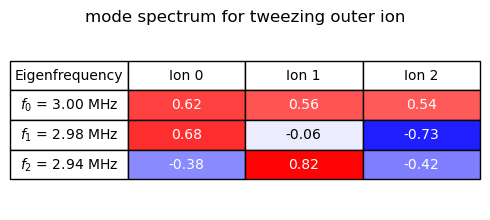

In [9]:
# Make figure and axis
fig, ax = plt.subplots(figsize=(5, 0.7 * len(tweezed_modes)))
ax.axis('tight')
ax.axis('off')

# Prepare table data
table_data = []
for index, (omega, etas) in enumerate(tweezed_modes):
    omega_mhz = omega / 1e6
    formatted_values = [f"{eta:.2f}" for eta in etas]
    omega_label = f"$f_{{{index}}}$ = {omega_mhz:.2f} MHz"
    table_data.append([omega_label] + formatted_values)

# Create column labels
column_labels = ["Eigenfrequency"] + [f"Ion {i}" for i in range(len(tweezed_modes))]

# Build the table
table = ax.table(cellText=table_data, colLabels=column_labels, loc='center', cellLoc='center')

# Style
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.6)

# Colormap normalization
etas_all = np.concatenate([etas for _, etas in tweezed_modes])
vmax = np.max(np.abs(etas_all)) + 0.01
norm = mcolors.Normalize(vmin=-vmax, vmax=vmax)
cmap = plt.get_cmap("bwr")

# Apply color to each η cell
for i in range(len(table_data)):
    for j in range(1, len(table_data[i])):  # skip frequency column
        value = float(table_data[i][j])
        color = cmap(norm(value))
        cell = table[i + 1, j]  # +1 to skip header
        cell.set_facecolor(color)
        cell.get_text().set_color("black" if -0.07 < value < 0.07 else "white")


table[0, 0].set_facecolor("white")

plt.tight_layout()
plt.title("mode spectrum for tweezing outer ion")
plt.show()


## Tweezing the center ion

In [10]:
w_rf_r = 2*pi*3e6
w_rf_a = 2*pi*400e3
w_tw_r = 2*pi*150e3
w_tw_a = None
N = 3
w_comb_r = combined_frequencies(N,[1],w_tw_r,w_tw_a,w_rf_r,w_rf_a)[0]
w_comb_a = combined_frequencies(N,[1],w_tw_r,w_tw_a,w_rf_r,w_rf_a)[2]
ueq = ion_spacing(N,w_rf_a)[0]
base_modes = individual_freqs_to_mode_vectors(N,[1],0,0,w_rf_r,w_rf_a,ueq)
tweezed_modes = individual_freqs_to_mode_vectors(N,[1],w_tw_r,w_tw_a,w_rf_r,w_rf_a,ueq)

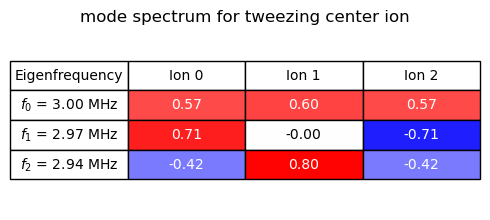

In [11]:
# Make figure and axis
fig, ax = plt.subplots(figsize=(5, 0.7 * len(tweezed_modes)))
ax.axis('tight')
ax.axis('off')

# Prepare table data
table_data = []
for index, (omega, etas) in enumerate(tweezed_modes):
    omega_mhz = omega / 1e6
    formatted_values = [f"{eta:.2f}" for eta in etas]
    omega_label = f"$f_{{{index}}}$ = {omega_mhz:.2f} MHz"
    table_data.append([omega_label] + formatted_values)

# Create column labels
column_labels = ["Eigenfrequency"] + [f"Ion {i}" for i in range(len(tweezed_modes))]

# Build the table
table = ax.table(cellText=table_data, colLabels=column_labels, loc='center', cellLoc='center')

# Style
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.6)

# Colormap normalization
etas_all = np.concatenate([etas for _, etas in tweezed_modes])
vmax = np.max(np.abs(etas_all)) + 0.01
norm = mcolors.Normalize(vmin=-vmax, vmax=vmax)
cmap = plt.get_cmap("bwr")

# Apply color to each η cell
for i in range(len(table_data)):
    for j in range(1, len(table_data[i])):  # skip frequency column
        value = float(table_data[i][j])
        color = cmap(norm(value))
        cell = table[i + 1, j]  # +1 to skip header
        cell.set_facecolor(color)
        cell.get_text().set_color("black" if -0.07 < value < 0.07 else "white")


table[0, 0].set_facecolor("white")

plt.tight_layout()
plt.title("mode spectrum for tweezing center ion")
plt.show()


# Change in mode frequencies from varying optical power of tweezer beam

In [12]:
#This cell just checks my math with Jerry's math to do the power sweep

w0 = 1.6e-6 #1 um beam diameter was quoted but my numbers only match Jerry's numbers if w0=4 um
P_opt = 6.1e10* (pi*w0**2)
pot = potential(omega_tweezer,linewidths,omega_res,P_opt,w0) #calculating the dipole potential from both S-P transitions
print(pot)
print((omega_tweezer_r(pot,w0,mBa137)/2*pi)/1e6) #MHz #calculates optical trap frequency based off a Taylor expansion at x=y=z=0 of the beam

-4.768093923839353e-25
2.8435889537075756


In [13]:
I = 6.1e10 #6.1 MW/cm^2
detuning = np.array([omega_res[0]-omega_tweezer,omega_res[1]-omega_tweezer])
print(detuning)
#some equations from Rajibul's paper for a sanity check
Rabi_squared = [(linewidths[0]*6*pi*c**2)/(hbar*omega_res[0]**3) * I , linewidths[1] *(6*pi*c**2)/(hbar*omega_res[1]**3) * I]
pot = hbar*Rabi_squared[0] / 4*detuning[0] + hbar*Rabi_squared[1] / 4*detuning[1]
print(omega_tweezer_r(pot,w0,mBa137)/(2*pi))


[2.75876685e+14 5.94369359e+14]
7.941757308510526e+19


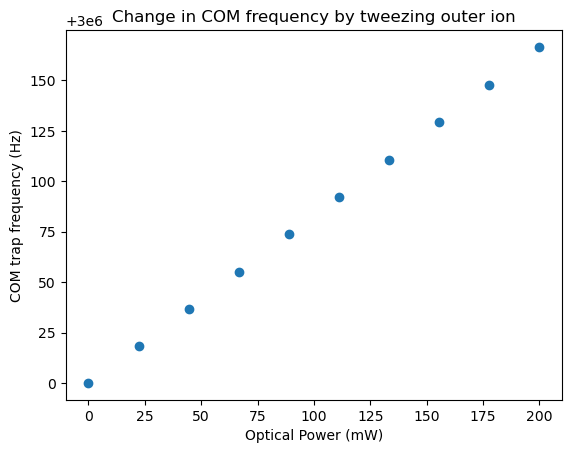

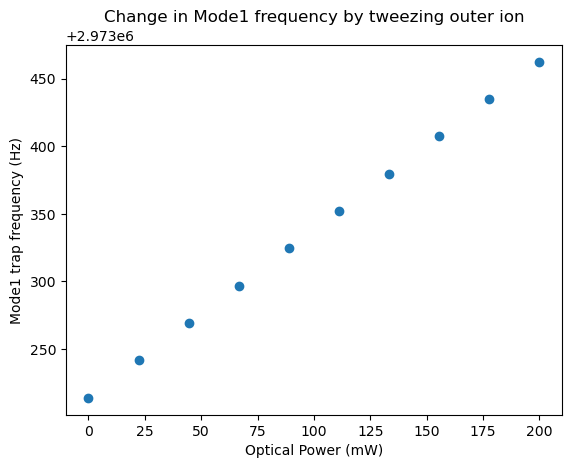

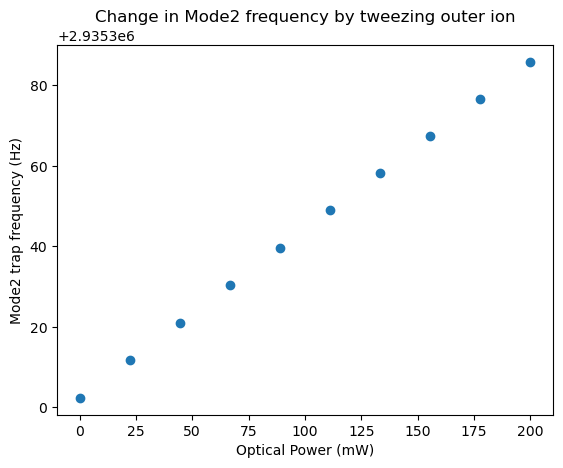

In [14]:
#going to sweep over powers from 0 mW to 200 mW and make 3 plots for 3 different ion positions
N = 3
P_opt = np.linspace(0,200e-3,10)
w0=4e-6
tweeze_0 = []
Modes = []
for P in range(len(P_opt)):
    tweeze_0.append(physical_params_to_radial_mode_vectors(N,ueq,[0],tweezer_wavelength,linewidths,omega_res,w_rf_a,w_rf_r,P_opt[P],w0,m,potential(omega_tweezer,linewidths,omega_res,P_opt[P],w0)))
        # Get modes for the tweezed system (both ions tweezed simultaneously)
COM_frequencies = np.array([tweeze_0[i][0][0] for i in range(len(P_opt))]) #Hz
plt.scatter(P_opt*1e3,COM_frequencies)
plt.xlabel("Optical Power (mW)")
plt.ylabel("COM trap frequency (Hz)")
plt.title("Change in COM frequency by tweezing outer ion")
plt.show()
Mode1_frequencies = np.array([tweeze_0[i][1][0] for i in range(len(P_opt))]) #Hz

plt.scatter(P_opt*1e3,Mode1_frequencies)
plt.xlabel("Optical Power (mW)")
plt.ylabel("Mode1 trap frequency (Hz)")
plt.title("Change in Mode1 frequency by tweezing outer ion")
plt.show()
Mode2_frequencies = np.array([tweeze_0[i][2][0] for i in range(len(P_opt))]) #Hz

plt.scatter(P_opt*1e3,Mode2_frequencies)
plt.xlabel("Optical Power (mW)")
plt.ylabel("Mode2 trap frequency (Hz)")
plt.title("Change in Mode2 frequency by tweezing outer ion")
plt.show()

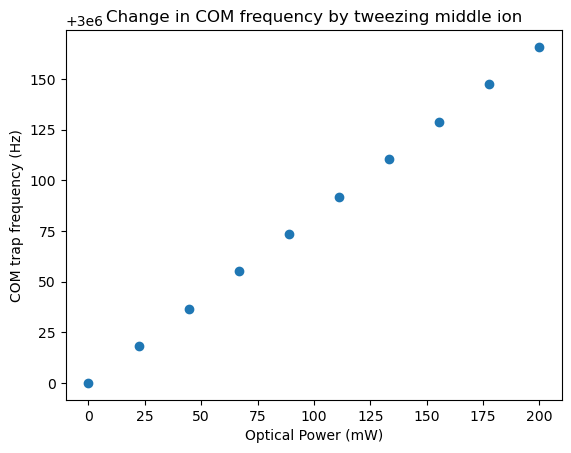

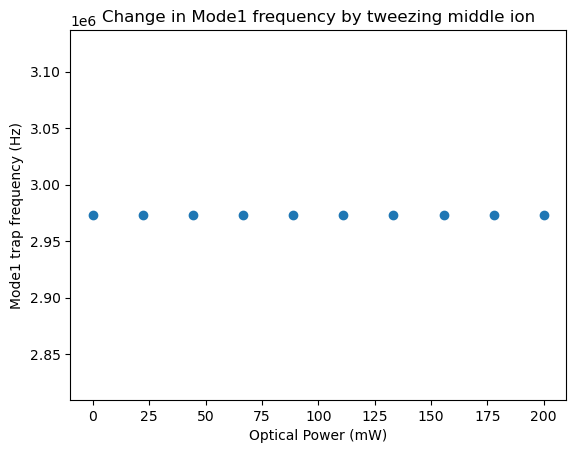

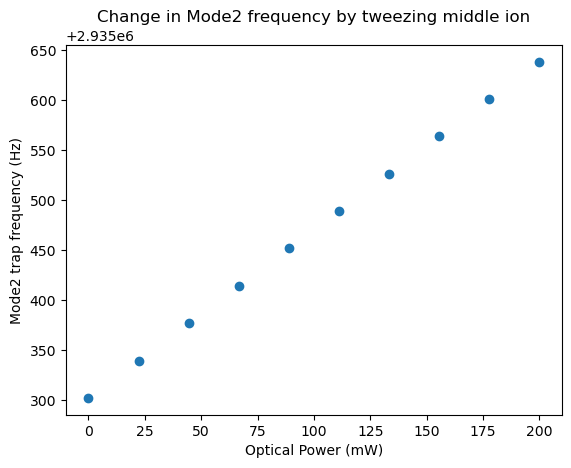

In [15]:
#going to sweep over powers from 0 mW to 200 mW and make 3 plots for 3 different ion positions
N = 3
P_opt = np.linspace(0,200e-3,10)
w0=4e-6
tweeze_0 = []
Modes = []
for P in range(len(P_opt)):
    tweeze_0.append(physical_params_to_radial_mode_vectors(N,ueq,[1],tweezer_wavelength,linewidths,omega_res,w_rf_a,w_rf_r,P_opt[P],w0,m,potential(omega_tweezer,linewidths,omega_res,P_opt[P],w0)))
        # Get modes for the tweezed system (both ions tweezed simultaneously)
COM_frequencies = np.array([tweeze_0[i][0][0] for i in range(len(P_opt))]) #Hz
plt.scatter(P_opt*1e3,COM_frequencies)
plt.xlabel("Optical Power (mW)")
plt.ylabel("COM trap frequency (Hz)")
plt.title("Change in COM frequency by tweezing middle ion")
plt.show()
Mode1_frequencies = np.array([tweeze_0[i][1][0] for i in range(len(P_opt))]) #Hz

plt.scatter(P_opt*1e3,Mode1_frequencies)
plt.xlabel("Optical Power (mW)")
plt.ylabel("Mode1 trap frequency (Hz)")
plt.title("Change in Mode1 frequency by tweezing middle ion")
plt.show()
Mode2_frequencies = np.array([tweeze_0[i][2][0] for i in range(len(P_opt))]) #Hz

plt.scatter(P_opt*1e3,Mode2_frequencies)
plt.xlabel("Optical Power (mW)")
plt.ylabel("Mode2 trap frequency (Hz)")
plt.title("Change in Mode2 frequency by tweezing middle ion")
plt.show()

In [16]:
I_real_suspicion = 96e-3 / (2*pi*4e-6**2)
cross_section0 = 3*(2*pi*c**2 / omega_res[0]**2)
cross_section1 = 3*(2*pi*c**2 / omega_res[1]**2)
I_sat_00 = (hbar*omega_res[0]*lifetimes[0])
I_sat_11 = (hbar*omega_res[0]*lifetimes[0])
print(I_real_suspicion/I_sat_00,I_real_suspicion/I_sat_11)
Rabif_0_sq =(linewidths[0]**2 * I_real_suspicion) / (2*I_sat_00)
print(np.sqrt(Rabif_0_sq))
Rabif_1_sq = (linewidths[1]**2 * I_real_suspicion) / (2*I_sat_11)
detuning0 = -omega_res[0] + omega_tweezer
detuning1 = -omega_res[1] + omega_tweezer
LightShift = Rabif_0_sq / 4*detuning0 + Rabif_1_sq/4*detuning1
print(LightShift/(2*pi))

2.5163821492180095e+19 2.5163821492180095e+19
3.344399197088438e+17
-4.903946089804278e+48


In [17]:
delta0 = omega_res[0]
delta1 = omega_res[1]
LightShift0 = omega_tweezer**2 / 4*delta0
LightShift1 = omega_tweezer**2/4*delta1
print(LightShift0/(2*pi))
print(LightShift1/(2*pi))
LightShift = ((LightShift0+LightShift1)/(2*pi))*1e-6
print(LightShift)

1.903758402036752e+45
2.0626267817848378e+45
3.966385183821589e+39


In [15]:
P_opt = 96e-3
w0 = 1e-6
test = potential(omega_tweezer,linewidths,omega_res,P_opt,w0)
print(test)
test_r = omega_tweezer_r(test,w0,mBa137)*1e-3/(2*pi)
print(test_r)

-2.388560945643428e-25
326.27426380966773


In [14]:
U = 150e6*hbar*2*pi
print(-1*U)
w0 = 1e-6
Jerry_r = omega_tweezer_r(U,w0,mBa137)*1e-3/(2*pi)
print(Jerry_r)

-9.939105225000002e-26
210.46907828154542


In [8]:
test - (-1*U )

-1.394650423143428e-25

In [17]:
print((test_r - Jerry_r)/test_r)

0.3549320261302538
